# Session 9

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sns.set_theme(style='whitegrid')
np.random.seed(7)

## Task 1 — Regplot: Instagram Likes vs Comments (10 Posts)

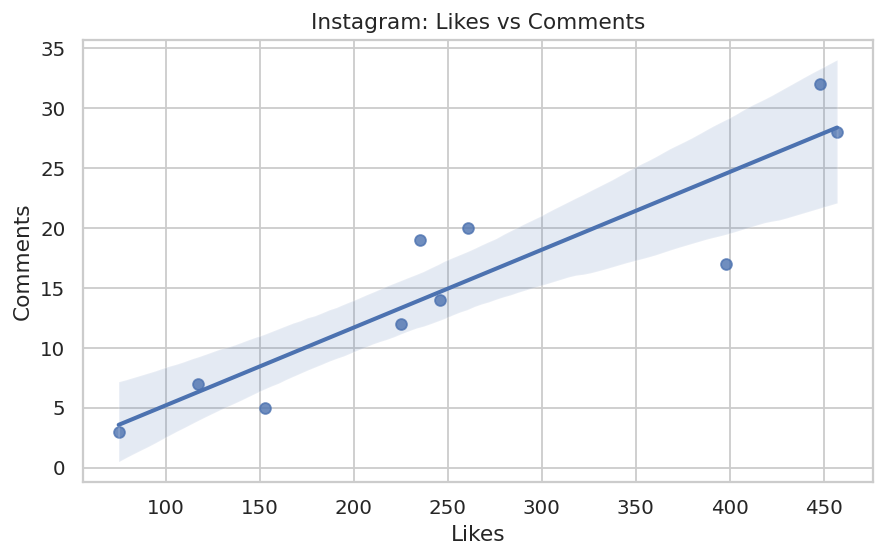

In [1]:
n = 10
likes = np.random.randint(50, 500, n)
comments = (likes * 0.06 + np.random.normal(0, 4, n)).clip(0, None).round()
posts_df = pd.DataFrame({'likes': likes, 'comments': comments})

plt.figure(figsize=(7, 4.5))
sns.regplot(data=posts_df, x='likes', y='comments')
plt.xlabel('Likes')
plt.ylabel('Comments')
plt.title('Instagram: Likes vs Comments')
plt.tight_layout()
plt.show()

## Task 2 — Lmplot: Order Price vs Delivery Time (15 Zomato-style Rows)

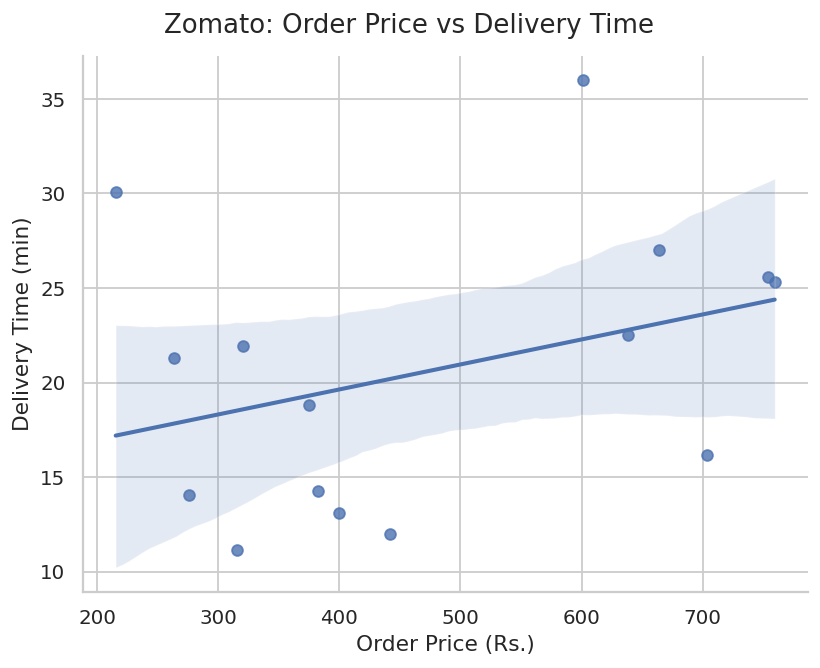

In [1]:
n2 = 15
order_price = np.random.uniform(150, 800, n2)
delivery_time2 = 15 + order_price * 0.015 + np.random.normal(0, 5, n2)
zomato_df = pd.DataFrame({'price': order_price, 'delivery_time': delivery_time2})

g = sns.lmplot(data=zomato_df, x='price', y='delivery_time', height=5, aspect=1.3)
g.set_axis_labels('Order Price (Rs.)', 'Delivery Time (min)')
g.figure.suptitle('Zomato: Order Price vs Delivery Time', y=1.03)
plt.show()

## Task 3 — Regplot with Lowess Smoothing: Playlist Songs vs Duration

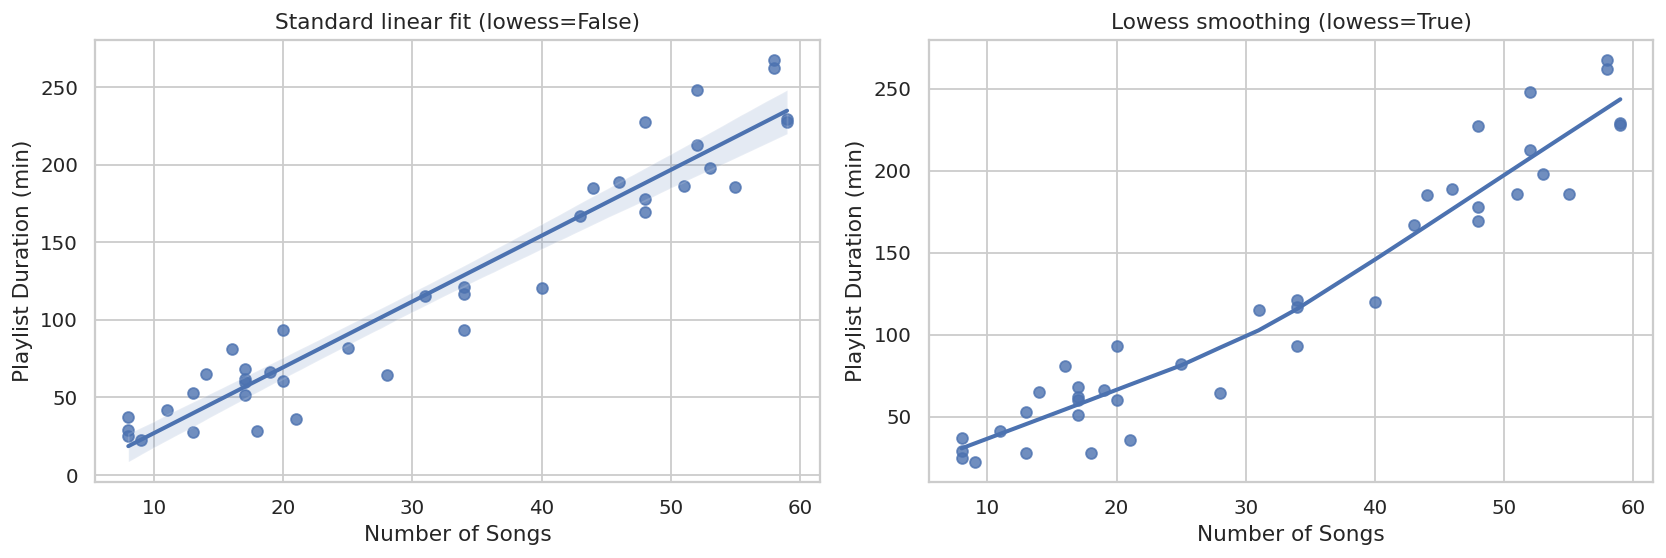

In [1]:
n3 = 40
num_songs = np.random.randint(5, 60, n3)
duration = num_songs * 3.5 + np.random.normal(0, 15, n3)
duration[num_songs > 40] += np.random.normal(30, 10, (num_songs > 40).sum())  # nonlinear kink for longer playlists
playlists_df = pd.DataFrame({'num_songs': num_songs, 'duration_min': duration})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.regplot(data=playlists_df, x='num_songs', y='duration_min', ax=axes[0])
axes[0].set_title('Standard linear fit (lowess=False)')
axes[0].set_xlabel('Number of Songs')
axes[0].set_ylabel('Playlist Duration (min)')

sns.regplot(data=playlists_df, x='num_songs', y='duration_min', lowess=True, ax=axes[1])
axes[1].set_title('Lowess smoothing (lowess=True)')
axes[1].set_xlabel('Number of Songs')
axes[1].set_ylabel('Playlist Duration (min)')

plt.tight_layout()
plt.show()

**Difference:** the standard fit forces a single straight line through the whole range, so it can't bend to follow the slight kink where longer playlists (40+ songs) run a bit longer per song than shorter ones. The lowess-smoothed curve flexes locally instead, tracking that bend rather than averaging it away — useful when the true relationship isn't purely linear across the whole range.

## Task 4 — Faceted Lmplot: YouTube Hours vs Exam Scores by Preparation Method

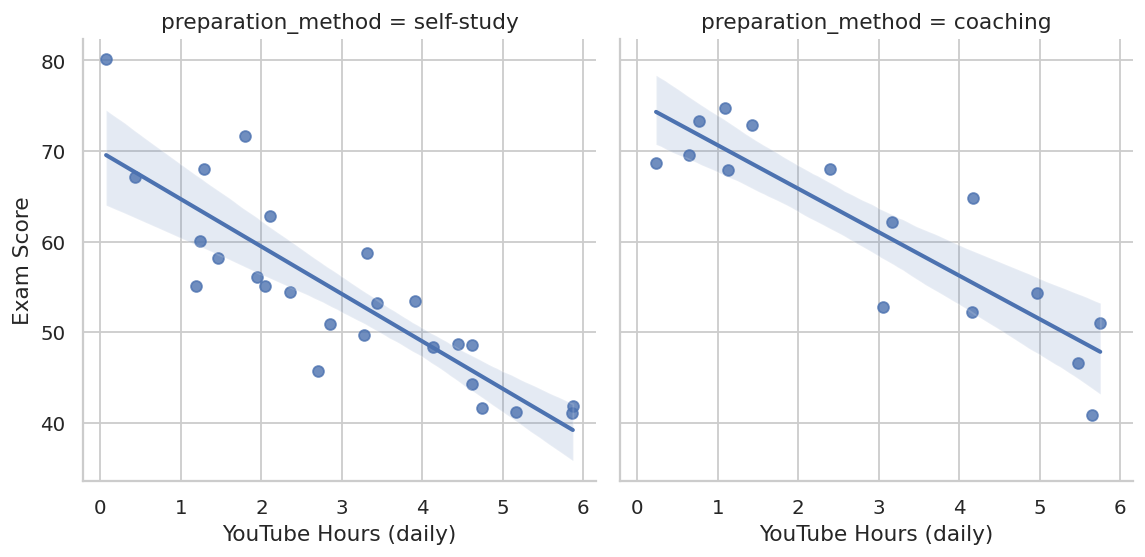

In [1]:
n4 = 40
prep_method = np.random.choice(['self-study', 'coaching'], n4)
youtube_hours4 = np.random.uniform(0, 6, n4)
base_score = np.where(prep_method == 'coaching', 78, 70)
exam_scores4 = (base_score - youtube_hours4 * 5 + np.random.normal(0, 5, n4)).clip(30, 100)

students_df4 = pd.DataFrame({
    'youtube_hours': youtube_hours4,
    'exam_score': exam_scores4,
    'preparation_method': prep_method,
})

g = sns.lmplot(data=students_df4, x='youtube_hours', y='exam_score', col='preparation_method', height=4.5)
g.set_axis_labels('YouTube Hours (daily)', 'Exam Score')
plt.show()

## Task 5 — Given Lmplot: Flipkart Price vs Reviews (Aesthetics Only, Same Regression Logic)

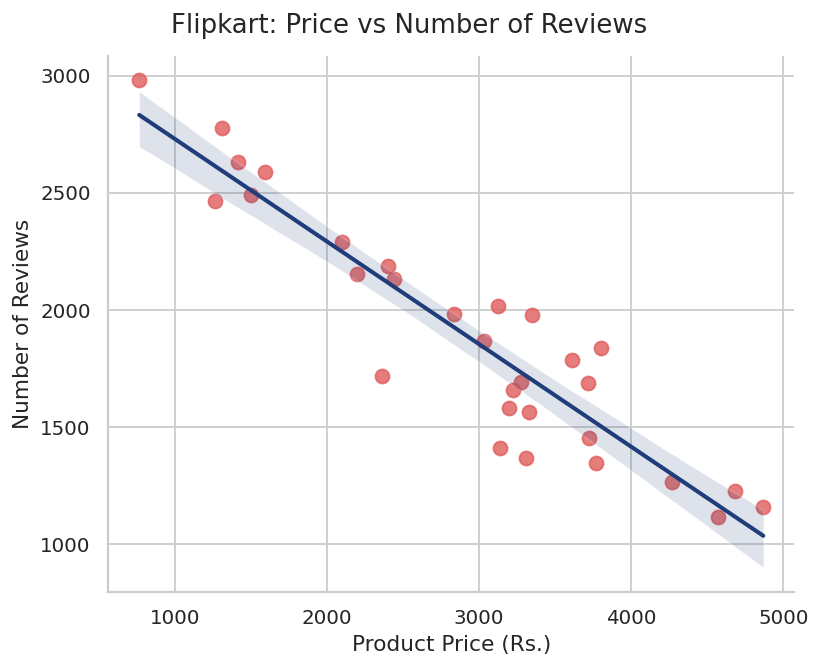

In [1]:
n5 = 30
flip_price = np.random.uniform(500, 5000, n5)
flip_reviews = (3000 - flip_price * 0.4 + np.random.normal(0, 300, n5)).clip(50, None)
flipkart_df5 = pd.DataFrame({'price': flip_price, 'reviews': flip_reviews})

g = sns.lmplot(data=flipkart_df5, x='price', y='reviews', height=5, aspect=1.3,
               scatter_kws={'color': '#e05c5c', 's': 60}, line_kws={'color': '#1f3d7a'})
g.set_axis_labels('Product Price (Rs.)', 'Number of Reviews')
g.figure.suptitle('Flipkart: Price vs Number of Reviews', y=1.03)
plt.show()